In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## For verification we will use pipe flow solutions. It has analytical solution as a Hagen–Poiseuille flow.

For this reason we run pipe flow computational case with initial settings:

- r = 0.00227 m
- Length of the pipe 0.05 m

Initial conditions:

- velocity v = 0.521646 m/s ~ 0.5 LPM
- kinematic viscosity nu = 1.48e-05 m^2/s
- density rho = 1  kg/m^3
- pressure at the inlet is zero gradient and 0 at the outlet



## Read the data:

In [37]:
pressure = pd.read_csv('data/pressure_at0.csv') #values at the inlet
data = pd.read_csv('data/velocity_outlet_25k_l045.csv') # values at the outlet#_50k_l005
data = data.dropna()
data.head()

,p,U:0,U:1,U:2,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2
0,0.059098,0.000000e+00,0.000000e+00,0.000000,1,0.000000,0,-0.002261,0.045
1,0.059098,-2.130900e-15,4.624400e-07,0.003841,1,0.000005,0,-0.002257,0.045
2,0.059098,-4.261800e-15,9.248800e-07,0.007683,1,0.000009,0,-0.002252,0.045
3,0.059098,-6.392800e-15,1.387300e-06,0.011524,1,0.000014,0,-0.002248,0.045
4,0.059098,-8.523700e-15,1.849800e-06,0.015366,1,0.000018,0,-0.002243,0.045


In [38]:
pressure.tail()

,p,U:0,U:1,U:2,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2
996,0.001492,-1.920000e-19,-1.862100e-19,1.0390,1,0.034347,0,0,0.034347
997,0.001119,-1.424300e-19,-1.362700e-19,1.0391,1,0.034382,0,0,0.034382
998,0.000746,-9.286200e-20,-8.632900e-20,1.0391,1,0.034416,0,0,0.034416
999,0.000373,-4.329300e-20,-3.638800e-20,1.0391,1,0.034451,0,0,0.034451
1000,0.000000,6.776300e-21,1.355300e-20,1.0391,1,0.034485,0,0,0.034485


## Calculate Reynolds number

In [39]:
#radius
R = 0.00227 
#density
rho = 1.0 
#Reynolds number
Re = rho*0.52*R*2/(1.48e-05)
print(Re)

159.51351351351352


According to this material https://www.kau.edu.sa/Files/0057863/Subjects/Chapter%208.pdf page 10&13

In [40]:
p = pressure['p'].mean() 
length = 0.045#0.0419

pressureGrad0 = p/length
pressureGrad0

5.271301932067933

In [41]:
#friction factor
f = 64/Re
dP = f*length*1*0.5216**2/(2*R*2)
pressureGrad = dP/length
dPdx = 1.48e-05*4/(0.00227**2)
print('f = {:2.4}, Pressure Gradient = {:2.4}, dpdx = {:2.4}'.format(f, pressureGrad, dPdx))

f = 0.4012, Pressure Gradient = 12.02, dpdx = 11.49


In [42]:
data['U'] = np.sqrt(data['U:1']**2 + data['U:2']**2 + data['U:0']**2) # velocity magnitude

data['r'] = np.sqrt(data['Points:0']**2 + data['Points:1']**2) # array how radius changing

data.head()

,p,U:0,U:1,U:2,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2,U,r
0,0.059098,0.000000e+00,0.000000e+00,0.000000,1,0.000000,0,-0.002261,0.045,0.000000,0.002261
1,0.059098,-2.130900e-15,4.624400e-07,0.003841,1,0.000005,0,-0.002257,0.045,0.003841,0.002257
2,0.059098,-4.261800e-15,9.248800e-07,0.007683,1,0.000009,0,-0.002252,0.045,0.007683,0.002252
3,0.059098,-6.392800e-15,1.387300e-06,0.011524,1,0.000014,0,-0.002248,0.045,0.011524,0.002248
4,0.059098,-8.523700e-15,1.849800e-06,0.015366,1,0.000018,0,-0.002243,0.045,0.015366,0.002243


In [49]:
r1 = np.linspace(-0.00227,0.00227,1000)
#data['exp']=(data['r']**2-R**2)*(1*rho/(4*1.48e-05))*pressureGrad 

data['exp']=(R**2-data['r']**2)*(1/(4*1.48e-05))*pressureGrad 
res=(R**2-r1**2)*(1/(4*1.48e-05))*pressureGrad 

In [50]:
x = np.arange(0,1001,1)

In [51]:
data_25k_l045 = pd.read_csv('data/velocity_outlet_25k_l045.csv')
data_25k_l045.dropna()

data_25k_l045['U'] = np.sqrt(data_25k_l045['U:1']**2 + data_25k_l045['U:2']**2 + data_25k_l045['U:0']**2) # velocity magnitude
data_25k_l045['r'] = np.sqrt(data_25k_l045['Points:0']**2 + data_25k_l045['Points:1']**2) # array how radius changing

In [57]:
data_50k_l005 = pd.read_csv('data/velocity_outlet_50k_l045.csv')
data_50k_l005.dropna()

data_50k_l005['U'] = np.sqrt(data_50k_l005['U:1']**2 + data_50k_l005['U:2']**2 + data_50k_l005['U:0']**2) # velocity magnitude
data_50k_l005['r'] = np.sqrt(data_50k_l005['Points:0']**2 + data_50k_l005['Points:1']**2) # array how radius changing
data_50k_l005['exp']=(R**2-data_50k_l005['r']**2)*(1/(4*1.48e-05))*pressureGrad 


x2 = np.arange(0,len(data_50k_l005),1)

In [58]:
len(x2)

1001

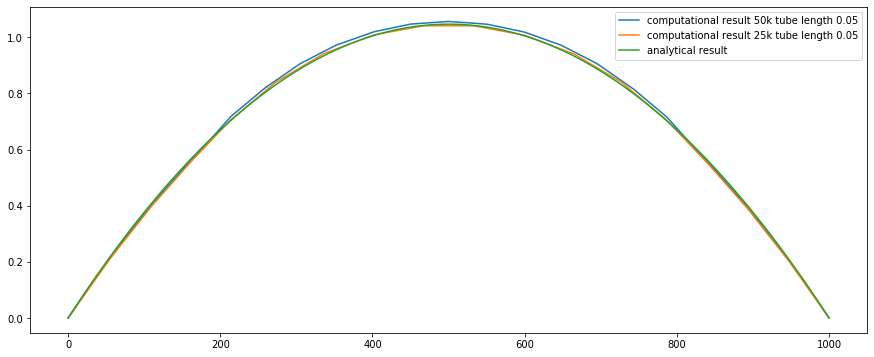

In [70]:
plt.figure(figsize=(15,6))
plt.plot(x2,data_50k_l005['U'],label = 'computational result 50k tube length 0.05')
plt.plot(x2,data_25k_l045['U'],label = 'computational result 25k tube length 0.05')
plt.plot(x2,data_50k_l005['exp'], label = 'analytical result')

plt.legend(loc="upper right");

In [60]:
exp = max(data_50k_l005['exp'])
print('Max velocity for analytical case {:2.4}'.format(max(data_50k_l005['exp'])))
print('Max velocity for 25k cells case {:2.4}'.format(max(data_25k_l045['U'])))
print('Max velocity for 50k cells case {:2.4}'.format(max(data_50k_l005['U'])))

Max velocity for analytical case 1.046
Max velocity for 25k cells case 1.041
Max velocity for 50k cells case 1.056


In [61]:
v_max = data_25k_l045['U'].max()
v_avg = v_max/2
v_initial = 0.521646
diff = np.abs(100-(100*v_avg/(v_initial)))
print('differenece between calculated velocity and analytical velocity is:',round(diff,4),'%')

differenece between calculated velocity and analytical velocity is: 0.258 %


## L2 norm

In [62]:
l2 = np.sqrt(np.sum((data_25k_l045['U']-data_50k_l005['exp'])**2)/np.sum(data_50k_l005['exp']**2))

print('l2 norm is:',round(l2,4))

l2 norm is: 0.0089


## CFL number

The CFL condition then has the following form:

$$C=\frac{u\,\Delta t}{\Delta x}\leq C_{\max }$$

In [63]:
# for the case with 25 k cells 
dt = 0.0001
dx = 0.05/100
v = 0.0521646
C = (v*dt)/dx

C

0.010432919999999998

# ANSYS Analysis

In [65]:
vel_25 = pd.read_csv('ANSYS/velocity_Diameter_25k.csv') 
vel_50 = pd.read_csv('ANSYS/velocity_Diameter_50k.csv')

vel_25.head()

,Node Number,X [ m ],Y [ m ],Z [ m ],Velocity [ m s^-1 ]
0,0.0,-0.002261,0.0,0.05,0.011937
1,1.0,-0.002257,0.0,0.05,0.015838
2,2.0,-0.002252,0.0,0.05,0.019739
3,3.0,-0.002248,0.0,0.05,0.023640
4,4.0,-0.002243,0.0,0.05,0.027541


In [66]:
vel_50.head()

,Node Number,X [ m ],Y [ m ],Z [ m ],Velocity [ m s^-1 ]
0,0.0,-0.002261,0.0,0.05,0.011628
1,1.0,-0.002257,0.0,0.05,0.015659
2,2.0,-0.002252,0.0,0.05,0.019690
3,3.0,-0.002248,0.0,0.05,0.023720
4,4.0,-0.002243,0.0,0.05,0.027751


In [67]:
print('Max velocity for 25k cells case {:2.4}'.format(vel_25[' Velocity [ m s^-1 ]'].max()))
print('Max velocity for 50k cells case {:2.4}'.format(vel_50[' Velocity [ m s^-1 ]'].max() ))

Max velocity for 25k cells case 1.022
Max velocity for 50k cells case 1.036


In [68]:
vel_ANSYS_25 = vel_25[' Velocity [ m s^-1 ]']
x_ANSYS_25   = vel_25[' X [ m ]']

vel_ANSYS_50 = vel_50[' Velocity [ m s^-1 ]']
x_ANSYS_50   = vel_50[' X [ m ]']

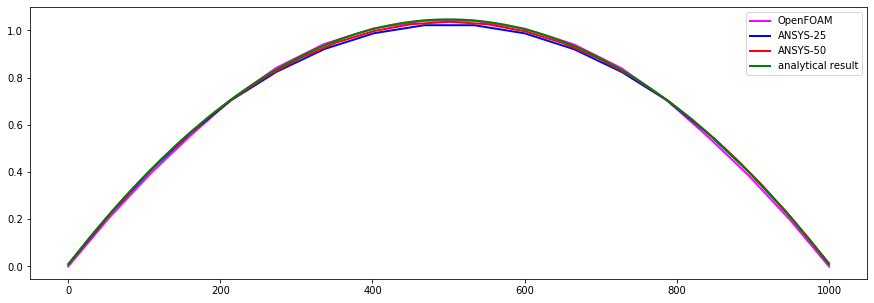

In [74]:
plt.figure(figsize=(15, 5))
plt.plot(x, data['U'],label = 'OpenFOAM',color='magenta',linewidth=2)
plt.plot(x2[1:-1],vel_ANSYS_25[:-1],label ='ANSYS-25',color='blue',linewidth=2)
plt.plot(x2[1:],vel_ANSYS_50,label ='ANSYS-50',color='red',linewidth=2)
plt.plot(x,data['exp'], label = 'analytical result',color='green',linewidth=2)
plt.legend(loc="upper right");

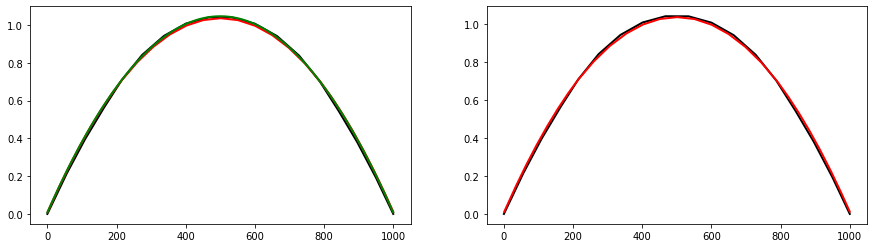

In [84]:
f = plt.figure(figsize=(15,4))
ax = f.add_subplot(121)
ax2 = f.add_subplot(122)
ax.plot(x, data['U'],label = 'OpenFOAM',color='black',linewidth=2)
ax.plot(x2[1:],vel_ANSYS_50,label ='ANSYS-50',color='red',linewidth=2)
ax.plot(x,data['exp'], label = 'analytical result',color='green',linewidth=2)

ax2.plot(x, data['U'],label = 'OpenFOAM',color='black',linewidth=2)
ax2.plot(x2[1:],vel_ANSYS_50,label ='ANSYS-50',color='red',linewidth=2)